In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zahranusratt/banking-fraud-detection-dataset/FraudShield_Banking_Data (1).csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/zahranusratt/banking-fraud-detection-dataset/FraudShield_Banking_Data (1).csv")

In [3]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  object 
 4   Transaction_Date                       49997 non-null  object 
 5   Transaction_Type                       49996 non-null  object 
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  object 
 8   Transaction_Location                   49994 non-null  object 
 9   Customer_Home_Location                 49996 non-null  object 
 10  Distance_From_Home                     49998 non-null  float64
 11  De

In [5]:
df.describe()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Merchant_ID,Distance_From_Home,Device_ID,Account_Balance (in Million),Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Previous_Fraud_Count
count,49997.000000,49990.000000,49991.000000,49993.000000,49998.000000,49991.000000,49991.000000,49991.000000,49995.000000,49991.000000,49996.000000,49989.000000,49997.000000
mean,550400.968898,54869.720744,4.999880,54951.375913,300.098564,552563.600088,20.993179,3.999460,12.520032,2.989098,5.016781,0.992798,0.500130
std,259677.602349,26052.824933,2.582025,25983.342481,172.848263,260186.451027,10.685467,2.002833,6.910709,1.413400,2.572913,0.816081,0.500005
min,100043.000000,10005.000000,1.000000,10001.000000,1.000000,100053.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,324445.000000,32259.250000,3.000000,32545.000000,150.000000,327643.500000,12.000000,2.000000,7.000000,2.000000,3.000000,0.000000,0.000000
50%,552115.000000,54720.500000,5.000000,54935.000000,301.000000,553372.000000,21.000000,4.000000,13.000000,3.000000,5.000000,1.000000,1.000000
75%,775942.000000,77542.000000,7.000000,77341.000000,449.000000,779903.500000,30.000000,6.000000,18.000000,4.000000,7.000000,2.000000,1.000000
max,999992.000000,99996.000000,9.000000,99996.000000,599.000000,999989.000000,39.000000,7.000000,24.000000,5.000000,9.000000,2.000000,1.000000


In [6]:
df.shape

(50000, 25)

In [7]:
df.isnull().sum()

Transaction_ID                            3
Customer_ID                              10
Transaction_Amount (in Million)           9
Transaction_Time                          9
Transaction_Date                          3
Transaction_Type                          4
Merchant_ID                               7
Merchant_Category                         9
Transaction_Location                      6
Customer_Home_Location                    4
Distance_From_Home                        2
Device_ID                                 9
IP_Address                                6
Card_Type                                 3
Account_Balance (in Million)              9
Daily_Transaction_Count                   9
Weekly_Transaction_Count                  5
Avg_Transaction_Amount (in Million)       9
Max_Transaction_Last_24h (in Million)     4
Is_International_Transaction              4
Is_New_Merchant                           5
Failed_Transaction_Count                 11
Unusual_Time_Transaction        

In [8]:
df=df.dropna()

In [9]:
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_17/173857299.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


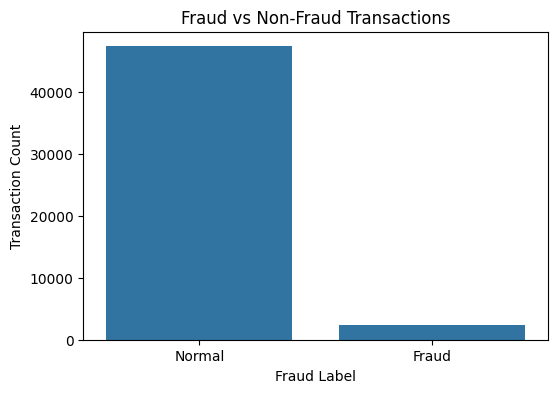

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="Fraud_Label", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Count")
plt.savefig("fraud_distribution.png", bbox_inches="tight")
plt.show()

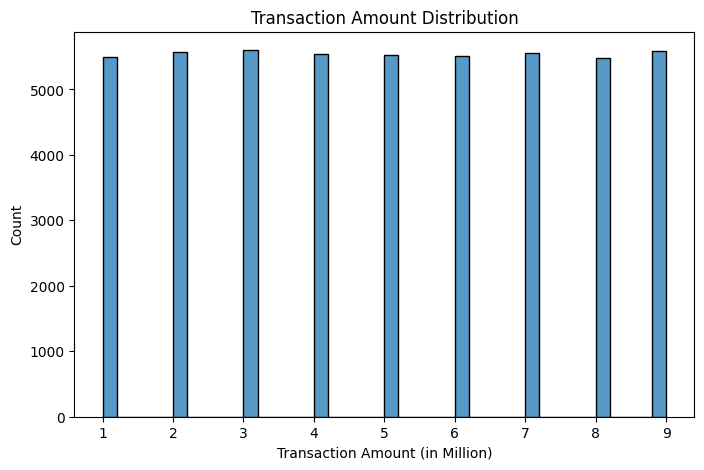

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Transaction_Amount (in Million)"], bins=40)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount (in Million)")
plt.savefig("transaction_distribution.png", bbox_inches="tight")
plt.show()

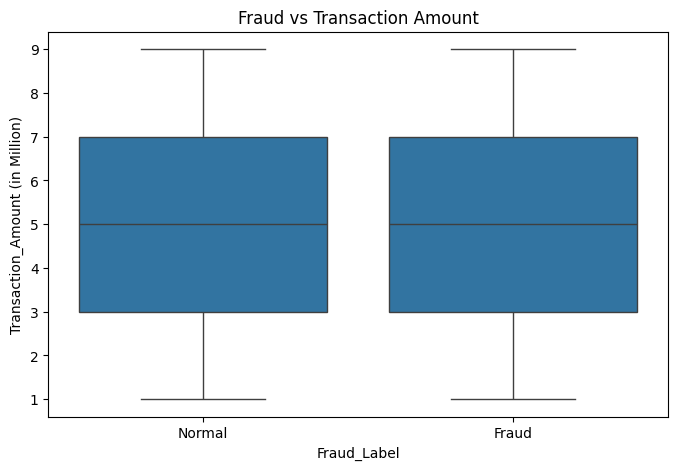

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Fraud_Label", y="Transaction_Amount (in Million)", data=df)
plt.title("Fraud vs Transaction Amount")
plt.savefig("fraud_vs_amount.png", bbox_inches="tight")
plt.show()

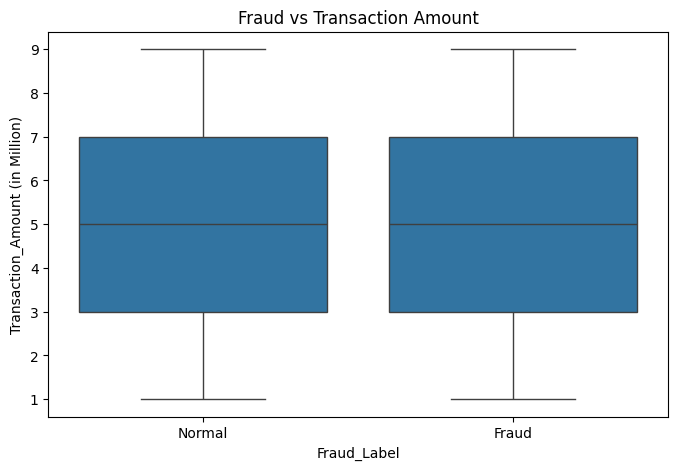

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Fraud_Label", y="Transaction_Amount (in Million)", data=df)
plt.title("Fraud vs Transaction Amount")
plt.savefig("fraud_vs_amount.png", bbox_inches="tight")
plt.show()

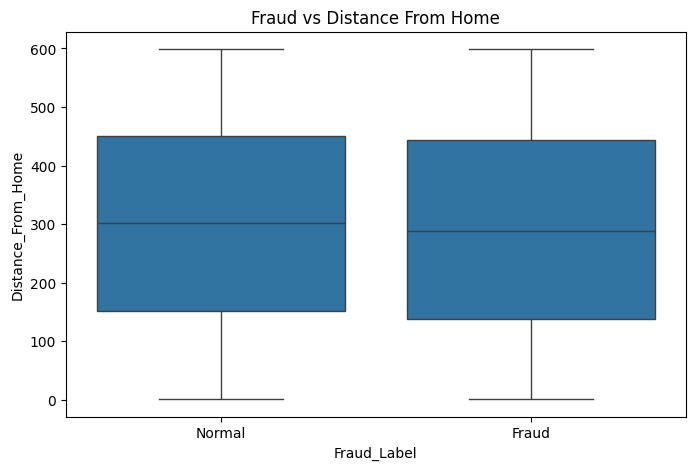

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Fraud_Label", y="Distance_From_Home", data=df)
plt.title("Fraud vs Distance From Home")
plt.savefig("distance_from_home.png", bbox_inches="tight")
plt.show()

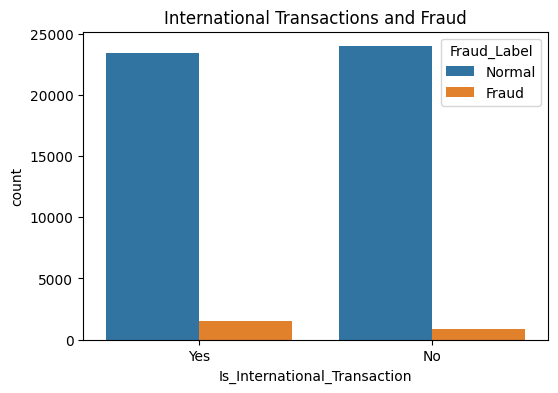

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="Is_International_Transaction", hue="Fraud_Label", data=df)
plt.title("International Transactions and Fraud")
plt.savefig("international_fraud.png", bbox_inches="tight")
plt.show()

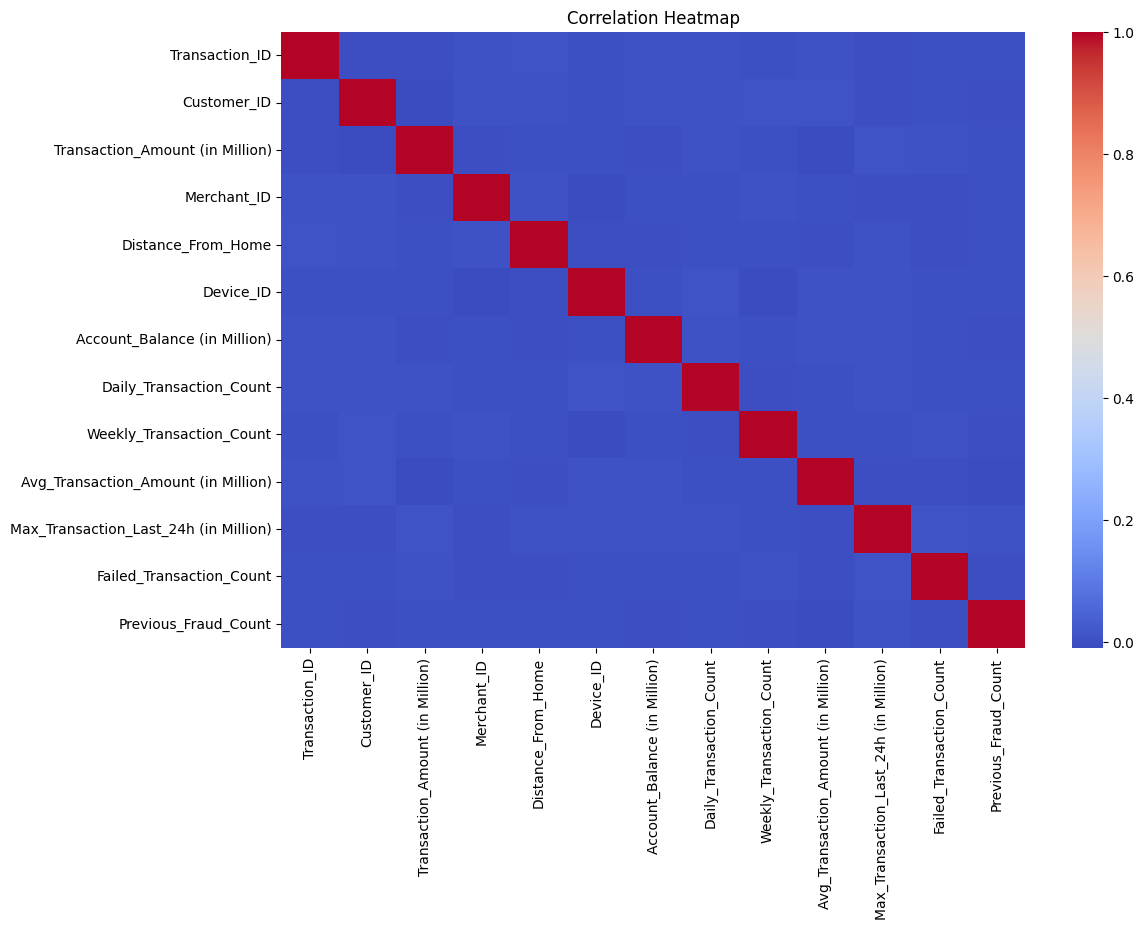

In [16]:
numeric_df = df.select_dtypes(include="number")
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()